In [ ]:
# ================================
# Clean CSV + Save Image
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure assets folder exists
os.makedirs("assets", exist_ok=True)

# --- Load & Clean CSV ---
df = pd.read_csv("data/output/speed_results.csv", skiprows=2)

# Keep only valid rows
df = df[pd.to_numeric(df["Frame Index"], errors="coerce").notna()]

# Convert to numeric
df["Frame Index"] = pd.to_numeric(df["Frame Index"])
df["Time (seconds)"] = pd.to_numeric(df["Time (seconds)"])
df["Speed LK (m/s)"] = pd.to_numeric(df["Speed LK (m/s)"])
df["Speed ORB (m/s)"] = pd.to_numeric(df["Speed ORB (m/s)"])

# Clean Note column
df["Note"] = df["Note"].fillna("")

# Reset index
df = df.reset_index(drop=True)

# --- Display Styled Table (Jupyter) ---
styled = df.head(10).style \
    .format({
        "Time (seconds)": "{:.3f}",
        "Speed LK (m/s)": "{:.3f}",
        "Speed ORB (m/s)": "{:.3f}"
    }) \
    .set_caption("CSV Preview – First 10 Frames") \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#374151"), ("color", "white")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])

display(styled)

# --- Save Table as Image ---
df_preview = df.head(10).copy()

# Round values for clean display
df_preview["Time (seconds)"] = df_preview["Time (seconds)"].round(3)
df_preview["Speed LK (m/s)"] = df_preview["Speed LK (m/s)"].round(3)
df_preview["Speed ORB (m/s)"] = df_preview["Speed ORB (m/s)"].round(3)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=df_preview.values,
    colLabels=df_preview.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#374151')
        cell.set_text_props(color='white')

#  FINAL FIX: hide index column completely
for (row, col), cell in table.get_celld().items():
    if col == -1:  # index column
        cell.set_text_props(text="")
        cell.set_facecolor('#111827')   # same dark background
        cell.set_edgecolor('#111827')   # hide borders

plt.savefig("assets/table_preview.png", dpi=300, bbox_inches='tight')
plt.close()

print("Table image saved to assets/table_preview.png ✅")

,Frame Index,Time (seconds),Speed LK (m/s),Speed ORB (m/s),Note
0,1,0.042,9.344,8.631,
1,2,0.083,9.423,8.591,
2,3,0.125,9.401,8.631,
3,4,0.167,9.571,8.631,
4,5,0.209,9.469,8.631,
5,6,0.250,9.571,8.631,
6,7,0.292,9.477,8.631,
7,8,0.334,9.799,8.949,
8,9,0.375,0.000,0.000,Tracking lost
9,10,0.417,9.572,8.631,


Table image saved to assets/table_preview.png ✅


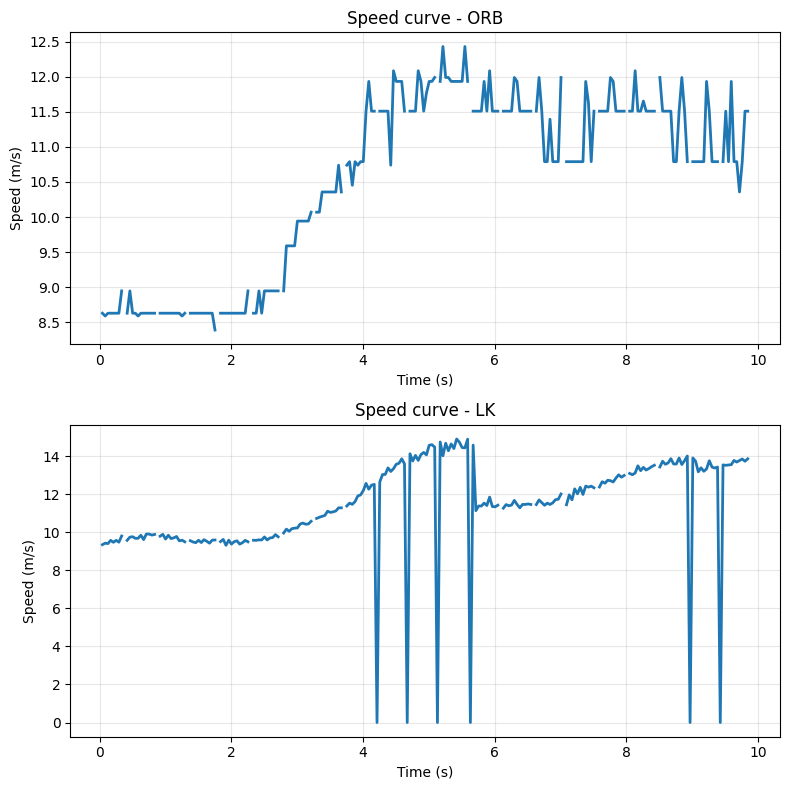

Graph saved to assets/speed_curves.png ✅


In [6]:
# ================================
# Save Speed Curves 
# ================================

import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure assets folder exists
os.makedirs("assets", exist_ok=True)

# Clean data (remove fake zeros from tracking loss)
df_clean = df.copy()
df_clean["Speed LK (m/s)"] = df_clean["Speed LK (m/s)"].replace(0, np.nan)
df_clean["Speed ORB (m/s)"] = df_clean["Speed ORB (m/s)"].replace(0, np.nan)

# Create figure
plt.figure(figsize=(8,8))

# --- ORB ---
plt.subplot(2,1,1)
plt.plot(df_clean["Time (seconds)"], df_clean["Speed ORB (m/s)"], linewidth=2)
plt.title("Speed curve - ORB")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.grid(alpha=0.3)

# --- LK ---
plt.subplot(2,1,2)
plt.plot(df_clean["Time (seconds)"], df_clean["Speed LK (m/s)"], linewidth=2)
plt.title("Speed curve - LK")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.grid(alpha=0.3)

# Layout fix
plt.tight_layout()

# Save image
plt.savefig("assets/speed_curves.png", dpi=300, bbox_inches='tight')

# Show (optional)
plt.show()

print("Graph saved to assets/speed_curves.png ✅")